# Gradient testing — cross-sectional measurement plan

Two competing accounts in the intro; data arbitrate.
- **Graded specialization:** lateralized-to-resected-side categories most disrupted; rank reverses by side.
- **Cooperative computation / redundancy:** symmetric categories more vulnerable.

**Primary ROIs:** FFA, PPA, LOC, VWFA. Sub-ROIs excluded from primary tests.

**Primary measures (test distinct constructs):**
- Sum-selectivity (lab-canonical, Blauch 2025) — decomposed into volume + mean activation as supplementary (Granovetter 2024 comparison).
- Distinctiveness (Liu Fisher-z) — representational specificity. Maps onto F30 Aim 3.

**Pre-specified confirmatory test:** RH-intact word_VWFA distinctiveness (Liu 2025 replication target). Single test, no FDR penalty.

**All other tests:** exploratory, FDR within measure.

**Notebook scope:** primary tests on FFA/PPA/LOC/VWFA + convergent evidence (1, 3–6 of plan). Distance test lives in `cross-sectional.ipynb`.

## 0. Setup

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t as tdist, spearmanr

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE    = Path(processed_dir)
LIU_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/liu_exact_replication_v2.csv')
ROI_BETAS_DIR = BASE / 'group_results' / 'roi_betas'
FIG_DIR = Path('/user_data/csimmon2/git_repos/sym_pt/C_results/figures/gradient_testing')
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE     = ['sub-017']
EXCLUDE_SES = [('sub-108', 2)]

PRIMARY_ROIS = ['face_FFA', 'house_PPA', 'object_LOC', 'word_VWFA']
ROI_TO_CAT   = {'face_FFA': 'face', 'house_PPA': 'house',
                'object_LOC': 'object', 'word_VWFA': 'word'}
CAT_SUBROIS = {  # used only for Proposal 5 sub-ROI sensitivity
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG'],
}
CATS4 = ['face', 'house', 'object', 'word']
CAT_COLOR = {'face': '#cc0066', 'house': '#009900',
             'object': '#0077cc', 'word': '#ff8800'}

N_PERM = 10000
SEED   = 42
FDR_METHOD = 'bh'  # within-measure FDR for exploratory tests; pre-specified test exempt

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'LIU_CSV : {LIU_CSV}')
print(f'ROI_BETAS_DIR : {ROI_BETAS_DIR}  (exists: {ROI_BETAS_DIR.exists()})')
print(f'FIG_DIR : {FIG_DIR}')

LIU_CSV : /user_data/csimmon2/git_repos/sym_pt/D_liu/liu_exact_replication_v2.csv
ROI_BETAS_DIR : /user_data/csimmon2/sym_pt/group_results/roi_betas  (exists: True)
FIG_DIR : /user_data/csimmon2/git_repos/sym_pt/C_results/figures/gradient_testing


## 1. Load data

In [3]:
le = pd.read_csv(LIU_CSV)
addon = LIU_CSV.parent / 'liu_exact_replication_v2_IFG_addon.csv'
if addon.exists():
    le = pd.concat([le, pd.read_csv(addon)], ignore_index=True)
le = le[~le['subject_id'].isin(EXCLUDE)]
le['ses_num'] = pd.to_numeric(le['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    le = le[~((le['subject_id'] == bad_sub) & (le['ses_num'] == bad_ses))]
le_summary = le.drop(columns=['pair', 'fisher_r']).drop_duplicates().copy()

# Controls -> first session, OTC patients -> last session
ctrl_all = le_summary[le_summary['status'] == 'control']
fs = ctrl_all.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'keep'})
ctrl_le = ctrl_all.merge(fs, on='subject_id')
ctrl_le = ctrl_le[ctrl_le['ses_num'] == ctrl_le['keep']].drop(columns='keep')

pt_all = le_summary[le_summary['group'] == 'OTC']
ls = pt_all.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'keep'})
pt_le = pt_all.merge(ls, on='subject_id')
pt_le = pt_le[pt_le['ses_num'] == pt_le['keep']].drop(columns='keep')

ctrl_subs = sorted(ctrl_le['subject_id'].unique())
otc_subs  = sorted(pt_le['subject_id'].unique())
print(f'Controls: {len(ctrl_subs)}   OTC patients: {len(otc_subs)}')

# Extraction outputs (for Proposals 3 & 4)
RESP_CSV  = ROI_BETAS_DIR / 'roi_per_condition_responses.csv'
SPLIT_CSV = ROI_BETAS_DIR / 'roi_split_half_loro.csv'
resp_df  = pd.read_csv(RESP_CSV)  if RESP_CSV.exists()  else None
split_df = pd.read_csv(SPLIT_CSV) if SPLIT_CSV.exists() else None
print(f'Per-condition responses : {"loaded " + str(len(resp_df)) + " rows" if resp_df is not None else "NOT FOUND"}')
print(f'Split-half LORO         : {"loaded " + str(len(split_df)) + " rows" if split_df is not None else "NOT FOUND"}')

Controls: 38   OTC patients: 22
Per-condition responses : loaded 1424 rows
Split-half LORO         : loaded 5696 rows


## 2. Helpers

In [4]:
def crawford(x, c):
    """Crawford & Howell (1998) modified t for single case vs control sample."""
    c = np.asarray(c); c = c[~np.isnan(c)]
    if len(c) < 3 or np.isnan(x): return np.nan, np.nan
    m, sd = c.mean(), c.std(ddof=1)
    if sd == 0: return np.nan, np.nan
    t = (x - m) / (sd * np.sqrt((len(c) + 1) / len(c)))
    p = 2 * (1 - tdist.cdf(abs(t), df=len(c) - 1))
    return t, p

def fdr_bh(p_values, alpha=0.05):
    """Benjamini-Hochberg FDR. Returns boolean mask of significant tests."""
    p = np.asarray(p_values, float)
    valid = ~np.isnan(p)
    p_valid = p[valid]
    n = len(p_valid)
    if n == 0: return np.zeros_like(p, bool)
    order = np.argsort(p_valid)
    ranked = p_valid[order]
    thresh = np.arange(1, n + 1) / n * alpha
    passed = ranked <= thresh
    max_idx = np.where(passed)[0].max() if passed.any() else -1
    sig_valid = np.zeros(n, bool)
    if max_idx >= 0:
        sig_valid[order[:max_idx + 1]] = True
    sig = np.zeros_like(p, bool)
    sig[valid] = sig_valid
    return sig

def pt_intact_hemi(sub):
    sd = pt_le[pt_le['subject_id'] == sub]
    if sd.empty: return None
    intact = sd['intact_hemi'].iloc[0]
    return 'l' if intact == 'left' else 'r' if intact == 'right' else None

def perm_diff_p(ctrl_vals, pt_vals, n_perm=N_PERM, seed=SEED):
    """Two-sided permutation p for mean(pt) - mean(ctrl)."""
    cv = np.asarray(ctrl_vals, float); cv = cv[~np.isnan(cv)]
    pv = np.asarray(pt_vals, float);   pv = pv[~np.isnan(pv)]
    if len(cv) < 3 or len(pv) < 2: return np.nan, np.nan
    obs = pv.mean() - cv.mean()
    pool = np.concatenate([cv, pv]); n_pt = len(pv)
    rng = np.random.RandomState(seed)
    null = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(pool)
        null[i] = perm[:n_pt].mean() - perm[n_pt:].mean()
    return obs, (np.abs(null) >= abs(obs)).mean()

def get_vals(df, subjects, roi, hemi, col, log10=False):
    out = []
    for s in subjects:
        v = df[(df['subject_id']==s) & (df['category']==roi) & (df['hemi']==hemi)][col]
        v = v.dropna().values
        if not len(v): continue
        x = v[0]
        if log10:
            if x > 0: out.append(np.log10(x))
        else:
            out.append(x)
    return np.array(out)

## 3. Pre-specified confirmatory test

**RH-intact word_VWFA distinctiveness** vs control right word_VWFA distinctiveness. Liu 2025 replication target. Single test — no FDR penalty.

Reported two ways:
1. Per-patient Crawford-Howell (each RH-intact patient vs control distribution)
2. Group-level permutation (mean of RH-intact patients vs control mean)

In [5]:
ROI_TGT, HEMI_TGT, COL_TGT = 'word_VWFA', 'r', 'liu_distinctiveness'
ctrl_target = ctrl_le[(ctrl_le['category']==ROI_TGT) & (ctrl_le['hemi']==HEMI_TGT)][COL_TGT].dropna().values
rh_intact_subs = [s for s in otc_subs if pt_intact_hemi(s) == HEMI_TGT]

print(f'Target : {ROI_TGT} {HEMI_TGT}-hemi {COL_TGT}')
print(f'Control distribution: n={len(ctrl_target)}, mean={ctrl_target.mean():+.4f}, sd={ctrl_target.std(ddof=1):.4f}')
print(f'RH-intact patients: n={len(rh_intact_subs)}\n')

# Per-patient Crawford-Howell
print('Per-patient Crawford-Howell (each RH-intact patient vs control distribution):')
print(f'  {"sub":12s} {"value":>10s} {"t":>8s} {"p":>8s} {"sig":>5s}')
print('  ' + '-' * 50)
ch_results = []
for s in rh_intact_subs:
    val = pt_le[(pt_le['subject_id']==s) & (pt_le['category']==ROI_TGT) & (pt_le['hemi']==HEMI_TGT)][COL_TGT]
    val = val.dropna().values
    if not len(val):
        print(f'  {s:12s}  no data')
        continue
    t, p = crawford(val[0], ctrl_target)
    sig = '*' if p < 0.05 else ''
    print(f'  {s:12s} {val[0]:>+10.4f} {t:>+8.3f} {p:>8.4f} {sig:>5s}')
    ch_results.append({'subject_id': s, 'value': val[0], 't': t, 'p': p})
ch_df = pd.DataFrame(ch_results)
ch_df.to_csv(FIG_DIR / 'prespecified_rVWFA_distinct_crawford.csv', index=False)

# Group-level permutation
pt_target = np.array([v for s in rh_intact_subs
                      for v in pt_le[(pt_le['subject_id']==s) & (pt_le['category']==ROI_TGT) &
                                     (pt_le['hemi']==HEMI_TGT)][COL_TGT].dropna().values])
delta, p_perm = perm_diff_p(ctrl_target, pt_target)
print(f'\nGroup-level permutation (RH-intact mean vs control mean):')
print(f'  ctrl mean = {ctrl_target.mean():+.4f}   pt mean = {pt_target.mean():+.4f}   Δ = {delta:+.4f}   p = {p_perm:.4f}')

Target : word_VWFA r-hemi liu_distinctiveness
Control distribution: n=37, mean=+0.3648, sd=0.5211
RH-intact patients: n=11

Per-patient Crawford-Howell (each RH-intact patient vs control distribution):
  sub               value        t        p   sig
  --------------------------------------------------
  sub-010         +0.7054   +0.645   0.5230      
  sub-021         +1.1482   +1.483   0.1467      
  sub-044         +0.7641   +0.756   0.4546      
  sub-066         +1.1431   +1.474   0.1492      
  sub-069         +0.3642   -0.001   0.9991      
  sub-078         +0.6439   +0.529   0.6004      
  sub-082         +0.3179   -0.089   0.9298      
  sub-090         +1.2372   +1.652   0.1072      
  sub-092         +0.9018   +1.017   0.3160      
  sub-099         +0.2864   -0.148   0.8828      
  sub-108         +0.4622   +0.184   0.8547      

Group-level permutation (RH-intact mean vs control mean):
  ctrl mean = +0.3648   pt mean = +0.7250   Δ = +0.3601   p = 0.0405


## 4. Primary measures × primary ROIs

Per-ROI permutation tests on FFA, PPA, LOC, VWFA × intact hemi × measure. **Inferential backbone of the gradient claim.** FDR-BH within measure (8 tests per measure: 4 ROIs × 2 sides).

In [6]:
# 4.1 — Sum-selectivity (log10), per-ROI permutation
print('=== Sum-selectivity (log10 sum_selec_norm), per-ROI permutation ===\n')
rows = []
for intact, lab in [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]:
    pt_subs_h = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    for roi in PRIMARY_ROIS:
        ct = get_vals(ctrl_le, ctrl_subs, roi, intact, 'sum_selec_norm', log10=True)
        pt = get_vals(pt_le, pt_subs_h, roi, intact, 'sum_selec_norm', log10=True)
        d, p = perm_diff_p(ct, pt)
        rows.append({'roi': roi, 'side': lab, 'n_ctrl': len(ct), 'n_pt': len(pt),
                     'ctrl_mean': ct.mean() if len(ct) else np.nan,
                     'pt_mean':   pt.mean() if len(pt) else np.nan,
                     'delta': d, 'p_raw': p})
ss_df = pd.DataFrame(rows)
ss_df['p_fdr_sig'] = fdr_bh(ss_df['p_raw'].values)
print(f'{"ROI":12s} {"Side":12s} {"ctrl_m":>9s} {"pt_m":>9s} {"Δ":>9s} {"p_raw":>8s} {"FDR sig":>9s}')
print('-' * 70)
for _, r in ss_df.iterrows():
    flag = '*' if r['p_fdr_sig'] else ('†' if r['p_raw'] < 0.05 else '')
    print(f'{r["roi"]:12s} {r["side"]:12s} {r["ctrl_mean"]:>+9.3f} {r["pt_mean"]:>+9.3f} '
          f'{r["delta"]:>+9.3f} {r["p_raw"]:>8.4f} {flag:>9s}')
ss_df.to_csv(FIG_DIR / 'primary_sumsel_perm.csv', index=False)
print('\n* = FDR-BH significant within measure   † = nominal p<0.05 only')

=== Sum-selectivity (log10 sum_selec_norm), per-ROI permutation ===



ROI          Side            ctrl_m      pt_m         Δ    p_raw   FDR sig
----------------------------------------------------------------------
face_FFA     LH (R-res)      +2.409    +2.348    -0.060   0.7380          
house_PPA    LH (R-res)      +2.733    +2.632    -0.101   0.4237          
object_LOC   LH (R-res)      +3.226    +2.799    -0.427   0.0015         *
word_VWFA    LH (R-res)      +2.265    +2.334    +0.070   0.7942          
face_FFA     RH (L-res)      +2.622    +2.546    -0.076   0.6914          
house_PPA    RH (L-res)      +2.770    +2.646    -0.124   0.5682          
object_LOC   RH (L-res)      +3.146    +3.046    -0.100   0.3179          
word_VWFA    RH (L-res)      +2.066    +2.093    +0.027   0.9330          

* = FDR-BH significant within measure   † = nominal p<0.05 only


In [7]:
# 4.2 — Sum-sel decomposition (volume + mean activation), supplementary (Granovetter 2024)
print('=== Sum-sel decomposition: volume (log10 voxel count) + mean activation ===\n')
for col, log in [('volume', True), ('mean_act', False)]:
    print(f'--- {col} {"(log10)" if log else ""} ---')
    rows = []
    for intact, lab in [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]:
        pt_subs_h = [s for s in otc_subs if pt_intact_hemi(s) == intact]
        for roi in PRIMARY_ROIS:
            ct = get_vals(ctrl_le, ctrl_subs, roi, intact, col, log10=log)
            pt = get_vals(pt_le, pt_subs_h, roi, intact, col, log10=log)
            d, p = perm_diff_p(ct, pt)
            rows.append({'measure': col, 'roi': roi, 'side': lab,
                         'ctrl_mean': ct.mean() if len(ct) else np.nan,
                         'pt_mean':   pt.mean() if len(pt) else np.nan,
                         'delta': d, 'p_raw': p})
    sub_df = pd.DataFrame(rows)
    sub_df['p_fdr_sig'] = fdr_bh(sub_df['p_raw'].values)
    print(f'{"ROI":12s} {"Side":12s} {"ctrl_m":>9s} {"pt_m":>9s} {"Δ":>9s} {"p_raw":>8s} {"FDR sig":>9s}')
    print('-' * 70)
    for _, r in sub_df.iterrows():
        flag = '*' if r['p_fdr_sig'] else ('†' if r['p_raw'] < 0.05 else '')
        print(f'{r["roi"]:12s} {r["side"]:12s} {r["ctrl_mean"]:>+9.3f} {r["pt_mean"]:>+9.3f} '
              f'{r["delta"]:>+9.3f} {r["p_raw"]:>8.4f} {flag:>9s}')
    sub_df.to_csv(FIG_DIR / f'primary_{col}_perm.csv', index=False)
    print()

=== Sum-sel decomposition: volume (log10 voxel count) + mean activation ===

--- volume (log10) ---
ROI          Side            ctrl_m      pt_m         Δ    p_raw   FDR sig
----------------------------------------------------------------------
face_FFA     LH (R-res)      +2.774    +2.710    -0.064   0.6901          
house_PPA    LH (R-res)      +3.301    +3.217    -0.084   0.4464          
object_LOC   LH (R-res)      +4.178    +3.792    -0.386   0.0012         *
word_VWFA    LH (R-res)      +2.772    +2.794    +0.022   0.9356          
face_FFA     RH (L-res)      +2.965    +2.858    -0.107   0.4969          
house_PPA    RH (L-res)      +3.355    +3.234    -0.121   0.5288          
object_LOC   RH (L-res)      +4.112    +3.974    -0.138   0.0862          
word_VWFA    RH (L-res)      +2.581    +2.559    -0.022   0.9394          

--- mean_act  ---
ROI          Side            ctrl_m      pt_m         Δ    p_raw   FDR sig
------------------------------------------------------------

In [8]:
# 4.3 — Distinctiveness, per-ROI permutation
print('=== Distinctiveness (liu_distinctiveness), per-ROI permutation ===\n')
rows = []
for intact, lab in [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]:
    pt_subs_h = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    for roi in PRIMARY_ROIS:
        ct = get_vals(ctrl_le, ctrl_subs, roi, intact, 'liu_distinctiveness')
        pt = get_vals(pt_le, pt_subs_h, roi, intact, 'liu_distinctiveness')
        d, p = perm_diff_p(ct, pt)
        rows.append({'roi': roi, 'side': lab, 'n_ctrl': len(ct), 'n_pt': len(pt),
                     'ctrl_mean': ct.mean() if len(ct) else np.nan,
                     'pt_mean':   pt.mean() if len(pt) else np.nan,
                     'delta': d, 'p_raw': p})
ds_df = pd.DataFrame(rows)
ds_df['p_fdr_sig'] = fdr_bh(ds_df['p_raw'].values)
print(f'{"ROI":12s} {"Side":12s} {"ctrl_m":>9s} {"pt_m":>9s} {"Δ":>9s} {"p_raw":>8s} {"FDR sig":>9s}')
print('-' * 70)
for _, r in ds_df.iterrows():
    flag = '*' if r['p_fdr_sig'] else ('†' if r['p_raw'] < 0.05 else '')
    print(f'{r["roi"]:12s} {r["side"]:12s} {r["ctrl_mean"]:>+9.3f} {r["pt_mean"]:>+9.3f} '
          f'{r["delta"]:>+9.3f} {r["p_raw"]:>8.4f} {flag:>9s}')
ds_df.to_csv(FIG_DIR / 'primary_distinct_perm.csv', index=False)

=== Distinctiveness (liu_distinctiveness), per-ROI permutation ===

ROI          Side            ctrl_m      pt_m         Δ    p_raw   FDR sig
----------------------------------------------------------------------
face_FFA     LH (R-res)      +0.671    +0.569    -0.102   0.3723          
house_PPA    LH (R-res)      +0.436    +0.116    -0.320   0.2042          
object_LOC   LH (R-res)      +1.051    +1.035    -0.016   0.9205          
word_VWFA    LH (R-res)      +0.637    +0.575    -0.062   0.6736          
face_FFA     RH (L-res)      +0.548    +0.718    +0.171   0.1857          
house_PPA    RH (L-res)      +0.495    +0.826    +0.331   0.2420          
object_LOC   RH (L-res)      +1.232    +1.279    +0.047   0.7823          
word_VWFA    RH (L-res)      +0.365    +0.725    +0.360   0.0405         †


## 5. Convergent evidence

Following the plan: (1) Control LI, (3) Selectivity rank-order, (4) Distinctiveness decomposition, (5) Sub-ROI agreement, (6) Rank correlation.

### 5.1 Control LI characterization

Per-subject LI = (L − R) / (L + R) on `sum_selec_norm`, primary ROIs only. Compare to Behrmann & Plaut 2020 / Nordt 2023 (placeholder; fill in literature values).

In [9]:
def subject_li(df, subject, roi):
    sd = df[(df['subject_id']==subject) & (df['category']==roi)]
    L = sd[sd['hemi']=='l']['sum_selec_norm'].dropna()
    R = sd[sd['hemi']=='r']['sum_selec_norm'].dropna()
    L = L[L>0]; R = R[R>0]
    if len(L)==0 or len(R)==0: return np.nan
    Lm, Rm = L.mean(), R.mean()
    return (Lm - Rm) / (Lm + Rm) if (Lm + Rm) > 0 else np.nan

li_rows = [{'subject_id': s, 'roi': r, 'category': ROI_TO_CAT[r],
            'LI': subject_li(ctrl_le, s, r)} for s in ctrl_subs for r in PRIMARY_ROIS]
li_df = pd.DataFrame(li_rows)

LIT_VALUES = {  # placeholder; fill in before paper
    'face':   {'Behrmann_Plaut_2020': None, 'Nordt_2023': None},
    'word':   {'Behrmann_Plaut_2020': None, 'Nordt_2023': None},
    'house':  {'Behrmann_Plaut_2020': None, 'Nordt_2023': None},
    'object': {'Behrmann_Plaut_2020': None, 'Nordt_2023': None},
}
print(f'{"ROI":12s} {"Cat":8s} {"N":>4s} {"Mean LI":>10s} {"SD":>8s} {"B&P 2020":>10s} {"Nordt 2023":>12s}')
print('-' * 70)
for roi in PRIMARY_ROIS:
    vals = li_df[li_df['roi']==roi]['LI'].dropna().values
    cat = ROI_TO_CAT[roi]
    bp = LIT_VALUES[cat]['Behrmann_Plaut_2020']; no = LIT_VALUES[cat]['Nordt_2023']
    bp_s = f'{bp:+.3f}' if bp is not None else '—'
    no_s = f'{no:+.3f}' if no is not None else '—'
    print(f'{roi:12s} {cat:8s} {len(vals):>4d} {vals.mean():>+10.3f} {vals.std(ddof=1):>8.3f} '
          f'{bp_s:>10s} {no_s:>12s}')
li_df.to_csv(FIG_DIR / 'control_LI_per_subject.csv', index=False)
print('\nCaveat: Nordt 2023 sample is developmental (5–12 yr); our control range may differ.')

ROI          Cat         N    Mean LI       SD   B&P 2020   Nordt 2023
----------------------------------------------------------------------
face_FFA     face       36     -0.208    0.382          —            —
house_PPA    house      38     -0.081    0.298          —            —
object_LOC   object     38     +0.089    0.161          —            —
word_VWFA    word       36     +0.116    0.465          —            —

Caveat: Nordt 2023 sample is developmental (5–12 yr); our control range may differ.


### 5.2 Selectivity rank-order within ROI

Does each primary ROI still respond preferentially to its category? Tests response magnitude, not contrast. Loads from `extract_roi_betas.py` outputs.

In [10]:
if resp_df is None:
    print('Skipped — run extract_roi_betas.py first.')
else:
    wide = resp_df.pivot_table(
        index=['subject_id', 'group', 'is_patient', 'intact_hemi', 'hemi', 'roi'],
        columns='condition', values='mean_response').reset_index()
    wide.columns.name = None

    rows = []
    for roi in PRIMARY_ROIS:
        canonical = ROI_TO_CAT[roi]
        for h in ('l', 'r'):
            ctrl = wide[(wide['roi']==roi) & (wide['hemi']==h) & (wide['group']=='control')]
            if len(ctrl) < 3: continue
            ctrl_profile = ctrl[CATS4].mean().values
            ctrl_top = CATS4[int(np.argmax(ctrl_profile))]
            ctrl_internal = []
            for _, r in ctrl.iterrows():
                this = r[CATS4].values.astype(float)
                others = ctrl[ctrl['subject_id'] != r['subject_id']][CATS4].mean().values
                rho, _ = spearmanr(this, others)
                ctrl_internal.append(rho)
            ctrl_internal_rho = np.nanmean(ctrl_internal)
            pt = wide[(wide['roi']==roi) & (wide['hemi']==h) & (wide['is_patient']==True)]
            pt = pt[pt['subject_id'].apply(lambda s: pt_intact_hemi(s) == h)]
            for _, r in pt.iterrows():
                this = r[CATS4].values.astype(float)
                rho, _ = spearmanr(this, ctrl_profile)
                pt_top = CATS4[int(np.argmax(this))]
                rows.append({'subject_id': r['subject_id'], 'roi': roi, 'hemi': h,
                             'ctrl_top': ctrl_top, 'pt_top': pt_top,
                             'top_matches_ctrl': pt_top == ctrl_top,
                             'top_matches_canonical': pt_top == canonical,
                             'rho_vs_ctrl_mean': rho,
                             'ctrl_internal_rho': ctrl_internal_rho})
    rank_df = pd.DataFrame(rows)
    rank_df.to_csv(FIG_DIR / 'rank_order_results.csv', index=False)
    print(f'{"ROI":12s} {"hemi":4s} {"n_pt":>4s} {"top=ctrl":>10s} {"top=canon":>11s} {"mean ρ":>10s} {"ctrl-internal ρ":>16s}')
    print('-' * 72)
    for roi in PRIMARY_ROIS:
        for h in ('l', 'r'):
            sub = rank_df[(rank_df['roi']==roi) & (rank_df['hemi']==h)]
            if not len(sub): continue
            print(f'{roi:12s} {h:4s} {len(sub):>4d} {sub["top_matches_ctrl"].mean():>9.0%}  '
                  f'{sub["top_matches_canonical"].mean():>10.0%}  '
                  f'{sub["rho_vs_ctrl_mean"].mean():>+10.3f}  '
                  f'{sub["ctrl_internal_rho"].iloc[0]:>+15.3f}')

ROI          hemi n_pt   top=ctrl   top=canon     mean ρ  ctrl-internal ρ
------------------------------------------------------------------------
face_FFA     l       8      100%        100%      +0.850           +0.722
face_FFA     r       9       89%         89%      +0.511           +0.800
house_PPA    l       8       62%         62%      +0.475           +0.717
house_PPA    r       9       89%         89%      +0.511           +0.678
object_LOC   l       8       88%         88%      +0.550           +0.739
object_LOC   r       9       56%         56%      +0.622           +0.778
word_VWFA    l       8       25%          0%      +0.700           +0.800
word_VWFA    r       9       44%          0%      +0.733           +0.839


### 5.3 Distinctiveness decomposition (within vs between)

Within-category vs between-category split-half components (Nordt 2023). Loads from `extract_roi_betas.py`. **Experimental** — LORO split-half computed inline, not validated against established lab pipeline.

In [11]:
if split_df is None:
    print('Skipped — run extract_roi_betas.py first.')
else:
    rows = []
    for (sub, roi, hemi), grp in split_df.groupby(['subject_id', 'roi', 'hemi']):
        M = np.full((4, 4), np.nan)
        for _, r in grp.iterrows():
            i, j = CATS4.index(r['cat_1']), CATS4.index(r['cat_2'])
            M[i, j] = r['r_loro_mean']
        canon = ROI_TO_CAT[roi]; ci = CATS4.index(canon)
        within_canon = M[ci, ci]
        between_canon = np.nanmean([M[ci, j] for j in range(4) if j != ci])
        rows.append({'subject_id': sub, 'roi': roi, 'hemi': hemi,
                     'group': grp['group'].iloc[0], 'is_patient': grp['is_patient'].iloc[0],
                     'intact_hemi': grp['intact_hemi'].iloc[0],
                     'within_canon': within_canon, 'between_canon': between_canon,
                     'distinct_canon': within_canon - between_canon})
    decomp_df = pd.DataFrame(rows)
    decomp_df.to_csv(FIG_DIR / 'decomposition_results.csv', index=False)

    print('Decomposition (canonical-category, intact hemi):')
    print(f'{"ROI":12s} {"Side":12s} {"Δwithin":>10s} {"p":>7s}  {"Δbetween":>10s} {"p":>7s}  {"Δdistinct":>10s} {"p":>7s}')
    print('-' * 84)
    perm_rows = []
    for intact, lab in [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]:
        pt_subs_h = [s for s in otc_subs if pt_intact_hemi(s) == intact]
        for roi in PRIMARY_ROIS:
            ct = decomp_df[(decomp_df['roi']==roi) & (decomp_df['hemi']==intact) & (decomp_df['group']=='control')]
            pt = decomp_df[(decomp_df['roi']==roi) & (decomp_df['hemi']==intact) & (decomp_df['subject_id'].isin(pt_subs_h))]
            if len(ct) < 3 or len(pt) < 2: continue
            d_w, p_w = perm_diff_p(ct['within_canon'], pt['within_canon'])
            d_b, p_b = perm_diff_p(ct['between_canon'], pt['between_canon'])
            d_d, p_d = perm_diff_p(ct['distinct_canon'], pt['distinct_canon'])
            print(f'{roi:12s} {lab:12s} {d_w:>+10.3f} {p_w:>7.4f}  '
                  f'{d_b:>+10.3f} {p_b:>7.4f}  {d_d:>+10.3f} {p_d:>7.4f}')
            perm_rows.append({'roi': roi, 'side': lab, 'd_within': d_w, 'p_within': p_w,
                              'd_between': d_b, 'p_between': p_b,
                              'd_distinct': d_d, 'p_distinct': p_d})
    pd.DataFrame(perm_rows).to_csv(FIG_DIR / 'decomposition_perm.csv', index=False)

Decomposition (canonical-category, intact hemi):
ROI          Side            Δwithin       p    Δbetween       p   Δdistinct       p
------------------------------------------------------------------------------------
face_FFA     LH (R-res)       -0.011  0.9097      -0.058  0.3827      +0.047  0.7602
house_PPA    LH (R-res)       -0.224  0.0460      +0.107  0.1780      -0.331  0.0565
object_LOC   LH (R-res)       -0.127  0.1057      +0.055  0.3629      -0.182  0.1623
word_VWFA    LH (R-res)       -0.152  0.1040      +0.076  0.0870      -0.228  0.0762
face_FFA     RH (L-res)       +0.032  0.6486      +0.008  0.8884      +0.024  0.8360
house_PPA    RH (L-res)       +0.037  0.7389      +0.039  0.6643      -0.001  0.9948
object_LOC   RH (L-res)       -0.031  0.7680      +0.007  0.8874      -0.038  0.7943
word_VWFA    RH (L-res)       -0.160  0.0232      -0.002  0.9708      -0.158  0.1187


### 5.4 Sub-ROI agreement (sensitivity)

For each category × side, do all sub-ROIs share the direction of disruption? If yes, category-level claim supported. If disagreement, claim narrows to specific sub-ROI(s).

In [12]:
rows = []
for intact, lab in [('l', 'LH (R-res)'), ('r', 'RH (L-res)')]:
    pt_subs_h = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    for cat, rois in CAT_SUBROIS.items():
        rois_present = [r for r in rois if r in le_summary['category'].unique()]
        for roi in rois_present:
            ct_ss = get_vals(ctrl_le, ctrl_subs, roi, intact, 'sum_selec_norm', log10=True)
            pt_ss = get_vals(pt_le, pt_subs_h, roi, intact, 'sum_selec_norm', log10=True)
            ct_ds = get_vals(ctrl_le, ctrl_subs, roi, intact, 'liu_distinctiveness')
            pt_ds = get_vals(pt_le, pt_subs_h, roi, intact, 'liu_distinctiveness')
            d_ss, p_ss = perm_diff_p(ct_ss, pt_ss)
            d_ds, p_ds = perm_diff_p(ct_ds, pt_ds)
            rows.append({'side': lab, 'category': cat, 'roi': roi,
                         'd_sumsel': d_ss, 'p_sumsel': p_ss,
                         'd_distinct': d_ds, 'p_distinct': p_ds})
agree_df = pd.DataFrame(rows)
agree_df.to_csv(FIG_DIR / 'subroi_agreement.csv', index=False)

print(f'{"Side":12s} {"Cat":8s} {"Sub-ROIs":40s} {"Sum-sel signs":>18s} {"Distinct signs":>18s}')
print('-' * 100)
for (side, cat), sub in agree_df.groupby(['side', 'category']):
    rois = ', '.join(sub['roi'].tolist())
    ss_signs = ' '.join('+' if v > 0 else ('-' if v < 0 else '0') for v in sub['d_sumsel'])
    ds_signs = ' '.join('+' if v > 0 else ('-' if v < 0 else '0') for v in sub['d_distinct'])
    ss_agree = (sub['d_sumsel'] > 0).all() or (sub['d_sumsel'] < 0).all()
    ds_agree = (sub['d_distinct'] > 0).all() or (sub['d_distinct'] < 0).all()
    print(f'{side:12s} {cat:8s} {rois:40s} '
          f'{ss_signs:>15s} {"✓" if ss_agree else "✗":>2s} '
          f'{ds_signs:>15s} {"✓" if ds_agree else "✗":>2s}')

Side         Cat      Sub-ROIs                                      Sum-sel signs     Distinct signs
----------------------------------------------------------------------------------------------------
LH (R-res)   face     face_FFA, face_STS                                   - -  ✓             - -  ✓
LH (R-res)   house    house_PPA, house_TOS                                 - +  ✗             - -  ✓
LH (R-res)   object   object_LOC, object_pF                                - -  ✓             - +  ✗
LH (R-res)   word     word_VWFA, word_STG, word_pSTG_liu, word_IFG         + + - +  ✗         - - + -  ✗
RH (L-res)   face     face_FFA, face_STS                                   - -  ✓             + +  ✓
RH (L-res)   house    house_PPA, house_TOS                                 - -  ✓             + -  ✗
RH (L-res)   object   object_LOC, object_pF                                - -  ✓             + -  ✗
RH (L-res)   word     word_VWFA, word_STG, word_pSTG_liu, word_IFG         + + + +  ✓  

### 5.5 |LI| × distinctiveness (continuous) — individual-difference test

Cleaner test than rank correlation: at each ROI, correlate per-subject |LI| with per-subject distinctiveness in controls (n=36–38). Tests gradient prediction at individual-difference level rather than category-pair level.

**Pre-specified direction:** graded specialization → **positive** correlation between |LI| and (1 − liu_distinctiveness) at preferred hemi. (Reminder: higher liu_distinctiveness = less distinct, so we use 1 − liu_distinctiveness or just flip sign expectations.)

**Patient test:** patients have only one intact hemi → cannot compute LI directly. Reported here for controls only; patient extension would need a different framing (e.g., correlating control-derived expected |LI| with patient distinctiveness loss).

In [13]:
from scipy.stats import wilcoxon

ROIS_3 = ['face_FFA', 'object_LOC', 'word_VWFA']
PRED_RANK = {
    'l': {'word_VWFA': 1, 'object_LOC': 2, 'face_FFA': 3},
    'r': {'face_FFA': 1, 'object_LOC': 2, 'word_VWFA': 3},
}

rows = []
for s in otc_subs:
    intact = pt_intact_hemi(s)
    if intact is None: continue
    obs, pred, rois_used = [], [], []
    for roi in ROIS_3:
        v = pt_le[(pt_le['subject_id']==s) & (pt_le['category']==roi) &
                  (pt_le['hemi']==intact)]['liu_distinctiveness'].dropna()
        if not len(v): continue
        obs.append(v.iloc[0])
        pred.append(PRED_RANK[intact][roi])
        rois_used.append(roi)
    if len(obs) < 3: continue
    rho, p = spearmanr(pred, obs)
    rows.append({'subject_id': s, 'intact_hemi': intact, 'rho': rho, 'p': p,
                 **{f'obs_{r}': v for r, v in zip(rois_used, obs)}})
rank_pt_df = pd.DataFrame(rows)
rank_pt_df.to_csv(FIG_DIR / 'per_patient_rank_test.csv', index=False)

print(f'{"sub":12s} {"intact":>7s} {"face":>8s} {"object":>8s} {"word":>8s} {"ρ":>7s} {"p":>7s}')
print('-' * 60)
for _, r in rank_pt_df.iterrows():
    print(f'{r["subject_id"]:12s} {r["intact_hemi"]:>7s} '
          f'{r.get("obs_face_FFA", np.nan):>+8.3f} '
          f'{r.get("obs_object_LOC", np.nan):>+8.3f} '
          f'{r.get("obs_word_VWFA", np.nan):>+8.3f} '
          f'{r["rho"]:>+7.2f} {r["p"]:>7.3f}')

print('\nGroup-level (per-intact-hemi):')
for intact, lab in [('l', 'LH-intact'), ('r', 'RH-intact')]:
    g = rank_pt_df[rank_pt_df['intact_hemi']==intact]['rho'].dropna()
    if len(g) < 2: continue
    try: w_stat, w_p = wilcoxon(g, alternative='greater')
    except ValueError: w_stat, w_p = np.nan, np.nan
    print(f'  {lab}: n={len(g)}, mean ρ = {g.mean():+.3f}, median = {g.median():+.3f}, '
          f'Wilcoxon (ρ>0) p = {w_p:.4f}')

g_all = rank_pt_df['rho'].dropna()
if len(g_all) >= 2:
    w_stat, w_p = wilcoxon(g_all, alternative='greater')
    print(f'  Combined: n={len(g_all)}, mean ρ = {g_all.mean():+.3f}, '
          f'Wilcoxon (ρ>0) p = {w_p:.4f}')

sub           intact     face   object     word       ρ       p
------------------------------------------------------------
sub-004            l   +0.056   +1.152   +0.397   -0.50   0.667
sub-005            l   +0.442   +1.457   +0.150   +0.50   0.667
sub-008            l   +0.451   +0.119   +0.070   +1.00   0.000
sub-010            r   +0.861   +2.113   +0.705   -0.50   0.667
sub-021            r   +1.270   +1.474   +1.148   -0.50   0.667
sub-039            l   +0.636   +1.423   +0.957   -0.50   0.667
sub-044            r   +0.018   +1.897   +0.764   +0.50   0.667
sub-066            r   +0.896   +0.931   +1.143   +1.00   0.000
sub-069            r   +0.962   +0.626   +0.364   -1.00   0.000
sub-074            l   -0.165   +0.990   +1.364   -1.00   0.000
sub-075            l   +0.993   +0.416   -0.061   +1.00   0.000
sub-076            l   +0.983   +1.554   +0.330   +0.50   0.667
sub-077            l   +0.853   +0.639   +0.894   -0.50   0.667
sub-078            r   +1.060   +1.614   +0

LH-intact (R-resect)      face_FFA      ctrl mean = +0.671 (n=38)  pt mean = +0.569 (n=11)
LH-intact (R-resect)      object_LOC    ctrl mean = +1.051 (n=38)  pt mean = +1.035 (n=11)
LH-intact (R-resect)      word_VWFA     ctrl mean = +0.637 (n=37)  pt mean = +0.575 (n=11)

RH-intact (L-resect)      face_FFA      ctrl mean = +0.548 (n=37)  pt mean = +0.718 (n=11)
RH-intact (L-resect)      object_LOC    ctrl mean = +1.232 (n=38)  pt mean = +1.279 (n=11)
RH-intact (L-resect)      word_VWFA     ctrl mean = +0.365 (n=37)  pt mean = +0.725 (n=11)



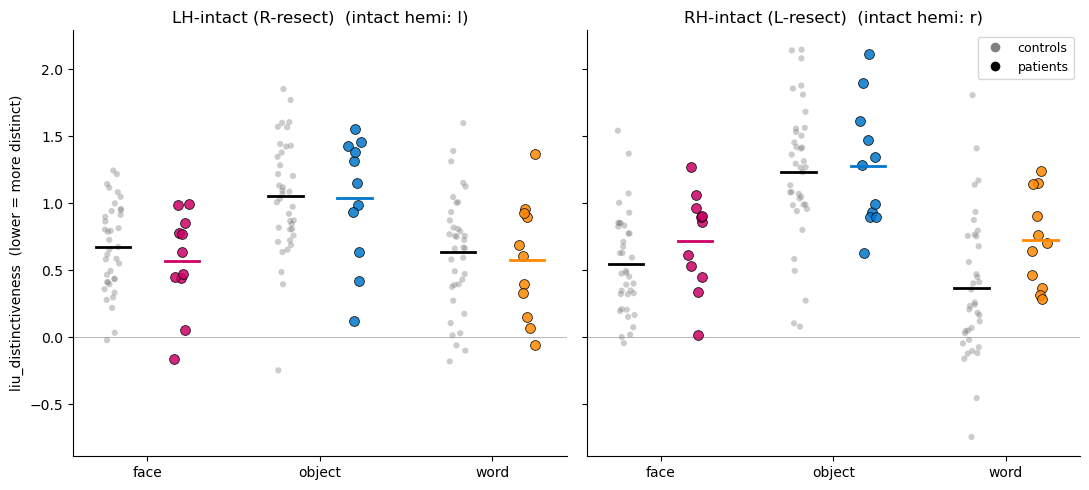

In [14]:
import matplotlib.pyplot as plt

ROIS_3 = ['face_FFA', 'object_LOC', 'word_VWFA']
LABELS = ['face', 'object', 'word']

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
RNG = np.random.RandomState(42)

for ax, intact, title in zip(axes, ['l', 'r'], ['LH-intact (R-resect)', 'RH-intact (L-resect)']):
    pt_subs_h = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    
    for xi, roi in enumerate(ROIS_3):
        # Control values at same hemi
        ctrl_vals = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']==intact)]['liu_distinctiveness'].dropna().values
        # Patient values at intact hemi
        pt_vals = []
        for s in pt_subs_h:
            v = pt_le[(pt_le['subject_id']==s) & (pt_le['category']==roi) & (pt_le['hemi']==intact)]['liu_distinctiveness'].dropna()
            if len(v): pt_vals.append(v.iloc[0])
        pt_vals = np.array(pt_vals)
        
        # Control mean as horizontal line + scatter
        if len(ctrl_vals):
            ax.scatter([xi - 0.2] * len(ctrl_vals) + RNG.uniform(-0.05, 0.05, len(ctrl_vals)),
                       ctrl_vals, s=20, color='gray', alpha=0.4, edgecolors='none', zorder=2)
            ax.plot([xi - 0.3, xi - 0.1], [ctrl_vals.mean()] * 2, color='black', lw=2, zorder=4)
        # Patient scatter
        if len(pt_vals):
            color = CAT_COLOR[ROI_TO_CAT[roi]]
            ax.scatter([xi + 0.2] * len(pt_vals) + RNG.uniform(-0.05, 0.05, len(pt_vals)),
                       pt_vals, s=50, color=color, alpha=0.85,
                       edgecolors='black', linewidth=0.6, zorder=5)
            ax.plot([xi + 0.1, xi + 0.3], [pt_vals.mean()] * 2, color=color, lw=2, zorder=6)
        
        # Print means
        ctrl_m = ctrl_vals.mean() if len(ctrl_vals) else np.nan
        pt_m = pt_vals.mean() if len(pt_vals) else np.nan
        print(f'{title:25s} {roi:12s}  ctrl mean = {ctrl_m:+.3f} (n={len(ctrl_vals)})  '
              f'pt mean = {pt_m:+.3f} (n={len(pt_vals)})')
    
    ax.set_xticks(range(len(ROIS_3)))
    ax.set_xticklabels(LABELS)
    ax.set_title(f'{title}  (intact hemi: {intact})')
    ax.axhline(0, color='gray', lw=0.4)
    if intact == 'l': ax.set_ylabel('liu_distinctiveness  (lower = more distinct)')
    print()

# Legend
from matplotlib.lines import Line2D
axes[1].legend([Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=8),
                Line2D([0],[0], marker='o', color='w', markerfacecolor='black', markersize=8)],
               ['controls', 'patients'], loc='best', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_distinctiveness_3rois.png', dpi=200, bbox_inches='tight')
plt.show()

LH-intact (R-resect)      face_FFA      Δ mean = -0.102  (n=11)
LH-intact (R-resect)      object_LOC    Δ mean = -0.016  (n=11)
LH-intact (R-resect)      word_VWFA     Δ mean = -0.062  (n=11)

RH-intact (L-resect)      face_FFA      Δ mean = +0.171  (n=11)
RH-intact (L-resect)      object_LOC    Δ mean = +0.047  (n=11)
RH-intact (L-resect)      word_VWFA     Δ mean = +0.360  (n=11)



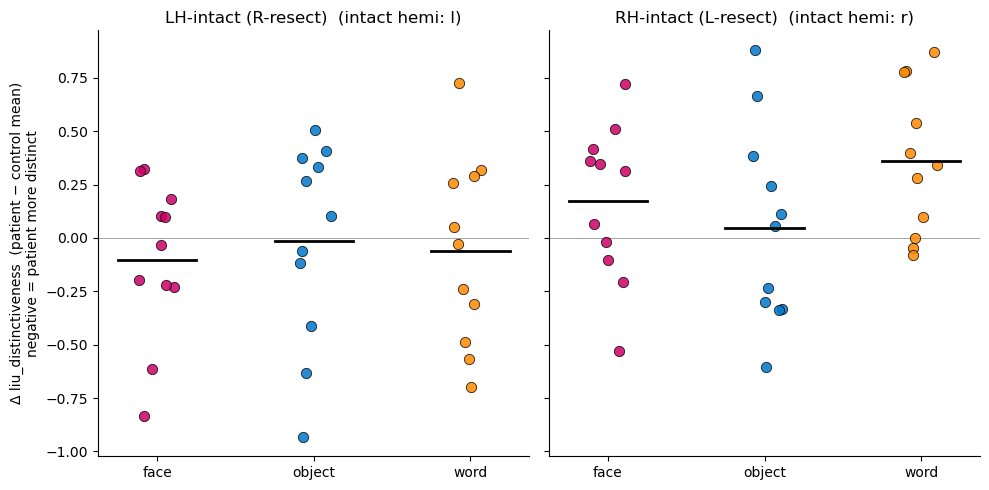

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
RNG = np.random.RandomState(42)

for ax, intact, title in zip(axes, ['l', 'r'], ['LH-intact (R-resect)', 'RH-intact (L-resect)']):
    pt_subs_h = [s for s in otc_subs if pt_intact_hemi(s) == intact]
    
    for xi, roi in enumerate(ROIS_3):
        ctrl_mean = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']==intact)]['liu_distinctiveness'].dropna().mean()
        deltas = []
        for s in pt_subs_h:
            v = pt_le[(pt_le['subject_id']==s) & (pt_le['category']==roi) & (pt_le['hemi']==intact)]['liu_distinctiveness'].dropna()
            if len(v): deltas.append(v.iloc[0] - ctrl_mean)
        deltas = np.array(deltas)
        if not len(deltas): continue
        
        color = CAT_COLOR[ROI_TO_CAT[roi]]
        ax.scatter(xi + RNG.uniform(-0.12, 0.12, len(deltas)), deltas,
                   s=55, color=color, alpha=0.85, edgecolors='black', linewidth=0.6, zorder=5)
        ax.plot([xi - 0.25, xi + 0.25], [deltas.mean()] * 2, color='black', lw=2, zorder=6)
        
        print(f'{title:25s} {roi:12s}  Δ mean = {deltas.mean():+.3f}  (n={len(deltas)})')
    
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xticks(range(len(ROIS_3)))
    ax.set_xticklabels(LABELS)
    ax.set_title(f'{title}  (intact hemi: {intact})')
    if intact == 'l': ax.set_ylabel('Δ liu_distinctiveness  (patient − control mean)\nnegative = patient more distinct')
    print()

plt.tight_layout()
plt.savefig(FIG_DIR / 'distinctiveness_deltas_3rois.png', dpi=200, bbox_inches='tight')
plt.show()

NameError: name 'ctrl_le_a' is not defined

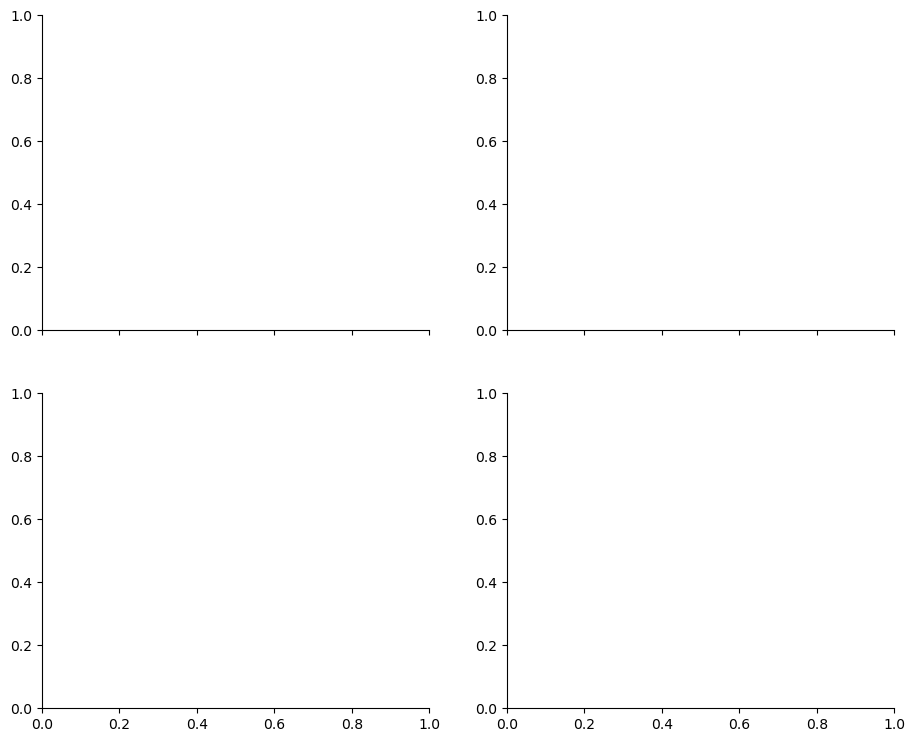

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True)
axes = axes.flatten()

for ax, roi in zip(axes, PRIMARY_ROIS):
    cat = ROI_TO_CAT[roi]
    
    # Controls: both hemis pooled, gray
    for h in ('l', 'r'):
        ct = ctrl_le_a[(ctrl_le_a['category']==roi) & (ctrl_le_a['hemi']==h)][['age', 'liu_distinctiveness']].dropna()
        ax.scatter(ct['age'], ct['liu_distinctiveness'], s=25, color='gray',
                   alpha=0.5, edgecolors='none', label='controls' if h=='l' else None)
    
    # Patients: at intact hemi, colored by intact side
    for intact, color, lab in [('l', '#1f77b4', 'LH-intact'), ('r', '#d62728', 'RH-intact')]:
        pt_subs_h = [s for s in otc_subs if pt_intact_hemi(s) == intact]
        pt = pt_le_a[(pt_le_a['subject_id'].isin(pt_subs_h)) &
                     (pt_le_a['category']==roi) & (pt_le_a['hemi']==intact)][['age','liu_distinctiveness']].dropna()
        ax.scatter(pt['age'], pt['liu_distinctiveness'], s=70, color=color,
                   alpha=0.85, edgecolors='black', linewidth=0.6, label=lab, zorder=5)
    
    ax.axvline(17, color='gray', lw=0.5, ls='--', alpha=0.5)
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('liu_distinctiveness  (lower = more distinct)')
    ax.set_title(f'{roi}  ({cat})')
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.savefig(FIG_DIR / 'age_x_distinctiveness_by_roi.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Patient group vs patient group — per-ROI Δ (vs same-hemi control mean) compared between LH-intact and RH-intact
print('=== LH-intact Δ vs RH-intact Δ (patient minus same-hemi control mean) ===\n')
print(f'{"ROI":12s} {"LH-Δ":>9s} {"RH-Δ":>9s} {"diff":>9s} {"p_perm":>8s}')
print('-' * 50)
rows = []
for roi in PRIMARY_ROIS:
    # LH-intact: patients at left, controls at left
    pt_LH = [s for s in otc_subs if pt_intact_hemi(s) == 'l']
    pt_RH = [s for s in otc_subs if pt_intact_hemi(s) == 'r']
    ct_L_mean = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']=='l')]['liu_distinctiveness'].dropna().mean()
    ct_R_mean = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']=='r')]['liu_distinctiveness'].dropna().mean()
    
    deltas_LH = []
    for s in pt_LH:
        v = pt_le[(pt_le['subject_id']==s) & (pt_le['category']==roi) & (pt_le['hemi']=='l')]['liu_distinctiveness'].dropna()
        if len(v): deltas_LH.append(v.iloc[0] - ct_L_mean)
    deltas_RH = []
    for s in pt_RH:
        v = pt_le[(pt_le['subject_id']==s) & (pt_le['category']==roi) & (pt_le['hemi']=='r')]['liu_distinctiveness'].dropna()
        if len(v): deltas_RH.append(v.iloc[0] - ct_R_mean)
    deltas_LH, deltas_RH = np.array(deltas_LH), np.array(deltas_RH)
    if len(deltas_LH) < 2 or len(deltas_RH) < 2:
        continue
    
    # Two-sample permutation
    obs = deltas_RH.mean() - deltas_LH.mean()
    pool = np.concatenate([deltas_LH, deltas_RH])
    n_RH = len(deltas_RH)
    rng = np.random.RandomState(SEED)
    null = np.empty(N_PERM)
    for i in range(N_PERM):
        perm = rng.permutation(pool)
        null[i] = perm[:n_RH].mean() - perm[n_RH:].mean()
    p = (np.abs(null) >= abs(obs)).mean()
    flag = '*' if p < 0.05 else ('†' if p < 0.10 else '')
    print(f'{roi:12s} {deltas_LH.mean():>+9.3f} {deltas_RH.mean():>+9.3f} {obs:>+9.3f} {p:>8.4f} {flag}')
    rows.append({'roi': roi, 'lh_delta_mean': deltas_LH.mean(), 'rh_delta_mean': deltas_RH.mean(),
                 'group_diff': obs, 'p_perm': p, 'n_LH': len(deltas_LH), 'n_RH': len(deltas_RH)})
pd.DataFrame(rows).to_csv(FIG_DIR / 'pt_group_vs_group_distinct.csv', index=False)

=== LH-intact Δ vs RH-intact Δ (patient minus same-hemi control mean) ===

ROI               LH-Δ      RH-Δ      diff   p_perm
--------------------------------------------------
face_FFA        -0.102    +0.171    +0.272   0.0982 †
house_PPA       -0.320    +0.331    +0.651   0.0246 *
object_LOC      -0.016    +0.047    +0.063   0.7509 
word_VWFA       -0.062    +0.360    +0.423   0.0240 *


### 5.6 Rank correlation across LH-intact and RH-intact (descriptive)

Spearman ρ across the 4 primary ROIs of Δs between sides. **Descriptive theoretical claim** — the inferential weight is in Section 4 per-ROI permutation tests. Reported here to characterize the rank pattern. n=4 underpowered; do not over-interpret.

In [ ]:
for measure, col, log in [('sum_sel', 'sum_selec_norm', True),
                          ('distinct', 'liu_distinctiveness', False)]:
    print(f'\n=== Measure: {measure} ===')
    dL, dR = [], []
    for roi in PRIMARY_ROIS:
        pt_LH = [s for s in otc_subs if pt_intact_hemi(s) == 'l']
        pt_RH = [s for s in otc_subs if pt_intact_hemi(s) == 'r']
        ct_L = get_vals(ctrl_le, ctrl_subs, roi, 'l', col, log10=log)
        pt_L = get_vals(pt_le,   pt_LH,    roi, 'l', col, log10=log)
        ct_R = get_vals(ctrl_le, ctrl_subs, roi, 'r', col, log10=log)
        pt_R = get_vals(pt_le,   pt_RH,    roi, 'r', col, log10=log)
        dL.append(pt_L.mean() - ct_L.mean() if (len(ct_L) >= 3 and len(pt_L) >= 2) else np.nan)
        dR.append(pt_R.mean() - ct_R.mean() if (len(ct_R) >= 3 and len(pt_R) >= 2) else np.nan)
    print(f'  {"ROI":12s} {"Δ_LH-intact":>14s} {"Δ_RH-intact":>14s}')
    for roi, l, r in zip(PRIMARY_ROIS, dL, dR):
        print(f'  {roi:12s} {l:>+14.4f} {r:>+14.4f}')
    dL_a, dR_a = np.array(dL), np.array(dR)
    valid = ~(np.isnan(dL_a) | np.isnan(dR_a))
    if valid.sum() >= 3:
        rho, _ = spearmanr(dL_a[valid], dR_a[valid])
        print(f'  Spearman ρ = {rho:+.3f}  (descriptive only; n=4, underpowered)')
    else:
        print('  Insufficient data for ρ')


=== Measure: sum_sel ===
  ROI             Δ_LH-intact    Δ_RH-intact
  face_FFA            -0.0603        -0.0759
  house_PPA           -0.1009        -0.1243
  object_LOC          -0.4272        -0.0996
  word_VWFA           +0.0698        +0.0266
  Spearman ρ = +0.800  (descriptive only; n=4, underpowered)

=== Measure: distinct ===
  ROI             Δ_LH-intact    Δ_RH-intact
  face_FFA            -0.1016        +0.1708
  house_PPA           -0.3200        +0.3308
  object_LOC          -0.0158        +0.0475
  word_VWFA           -0.0624        +0.3601
  Spearman ρ = -0.400  (descriptive only; n=4, underpowered)


## 6. Summary & open issues

- **Pre-specified confirmatory test:** RH-intact rVWFA distinctiveness — see Section 3.
- **Inferential backbone:** per-ROI permutation tests in Section 4, FDR within measure.
- **Convergent evidence:** Sections 5.1–5.5.
- **Rank correlation (5.5):** descriptive only. n=4 underpowered.

**Open issues:**
1. `LIT_VALUES` placeholder — fill in Behrmann & Plaut 2020 / Nordt 2023.
2. Sections 5.2 and 5.3 require `extract_roi_betas.py` outputs.
3. Decomposition (5.3) is experimental — flag in any write-up.
4. Distance test lives in `cross-sectional.ipynb`, not here.

In [ ]:
print('=== Patient group vs patient group: LH-intact (at L) vs RH-intact (at R) ===\n')

def two_sample_perm(a, b, n_perm=N_PERM, seed=SEED):
    a, b = np.asarray(a, float), np.asarray(b, float)
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2: return np.nan, np.nan
    obs = b.mean() - a.mean()
    pool = np.concatenate([a, b])
    n_b = len(b)
    rng = np.random.RandomState(seed)
    null = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(pool)
        null[i] = perm[:n_b].mean() - perm[n_b:].mean()
    return obs, (np.abs(null) >= abs(obs)).mean()

pt_LH = [s for s in otc_subs if pt_intact_hemi(s) == 'l']
pt_RH = [s for s in otc_subs if pt_intact_hemi(s) == 'r']

# Compute control centroids for distance (per ROI × hemi, 2D x,y from native peaks)
centroids = {}
for roi in PRIMARY_ROIS:
    for h in ('l', 'r'):
        c = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']==h)][['peak_x_native','peak_y_native']].dropna()
        centroids[(roi, h)] = (c['peak_x_native'].mean(), c['peak_y_native'].mean()) if len(c) else (np.nan, np.nan)

def dist_to_centroid(df, sub, roi, hemi):
    r = df[(df['subject_id']==sub) & (df['category']==roi) & (df['hemi']==hemi)]
    if not len(r): return np.nan
    cx, cy = centroids[(roi, hemi)]
    if np.isnan(cx): return np.nan
    return float(np.sqrt((r['peak_x_native'].iloc[0]-cx)**2 + (r['peak_y_native'].iloc[0]-cy)**2))

print(f'{"Measure":15s} {"ROI":12s} {"LH-mean":>10s} {"RH-mean":>10s} {"diff":>10s} {"p_perm":>8s}')
print('-' * 72)
all_rows = []
for measure_name, col, log10 in [('sum_sel', 'sum_selec_norm', True),
                                  ('distinct', 'liu_distinctiveness', False),
                                  ('distance_2d', None, False)]:
    for roi in PRIMARY_ROIS:
        if col is None:
            lh_vals = np.array([dist_to_centroid(pt_le, s, roi, 'l') for s in pt_LH])
            rh_vals = np.array([dist_to_centroid(pt_le, s, roi, 'r') for s in pt_RH])
        else:
            lh_vals = get_vals(pt_le, pt_LH, roi, 'l', col, log10=log10)
            rh_vals = get_vals(pt_le, pt_RH, roi, 'r', col, log10=log10)
        d, p = two_sample_perm(lh_vals, rh_vals)
        flag = '*' if (not np.isnan(p) and p < 0.05) else ('†' if (not np.isnan(p) and p < 0.10) else '')
        print(f'{measure_name:15s} {roi:12s} '
              f'{np.nanmean(lh_vals):>+10.3f} {np.nanmean(rh_vals):>+10.3f} '
              f'{d:>+10.3f} {p:>8.4f} {flag}')
        all_rows.append({'measure': measure_name, 'roi': roi,
                         'lh_mean': np.nanmean(lh_vals), 'rh_mean': np.nanmean(rh_vals),
                         'diff': d, 'p_perm': p,
                         'n_LH': sum(~np.isnan(lh_vals)), 'n_RH': sum(~np.isnan(rh_vals))})
    print()

pd.DataFrame(all_rows).to_csv(FIG_DIR / 'pt_group_vs_group_all_measures.csv', index=False)

=== Patient group vs patient group: LH-intact (at L) vs RH-intact (at R) ===

Measure         ROI             LH-mean    RH-mean       diff   p_perm
------------------------------------------------------------------------
sum_sel         face_FFA         +2.348     +2.546     +0.197   0.5603 
sum_sel         house_PPA        +2.632     +2.646     +0.014   0.9447 
sum_sel         object_LOC       +2.799     +3.046     +0.247   0.3250 
sum_sel         word_VWFA        +2.334     +2.093     -0.242   0.5563 

distinct        face_FFA         +0.569     +0.718     +0.149   0.3507 
distinct        house_PPA        +0.116     +0.826     +0.710   0.0162 *
distinct        object_LOC       +1.035     +1.279     +0.244   0.2358 
distinct        word_VWFA        +0.575     +0.725     +0.150   0.3814 

distance_2d     face_FFA        +13.906    +12.514     -1.392   0.6618 
distance_2d     house_PPA       +20.954    +24.693     +3.739   0.4137 
distance_2d     object_LOC      +12.354    +15.443     

In [19]:
pt_LH = [s for s in otc_subs if pt_intact_hemi(s) == 'l']
pt_RH = [s for s in otc_subs if pt_intact_hemi(s) == 'r']
def two_sample_perm(a, b, n_perm=N_PERM, seed=SEED):
    a, b = np.asarray(a, float), np.asarray(b, float)
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2: return np.nan, np.nan
    obs = b.mean() - a.mean()
    pool = np.concatenate([a, b])
    n_b = len(b)
    rng = np.random.RandomState(seed)
    null = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(pool)
        null[i] = perm[:n_b].mean() - perm[n_b:].mean()
    return obs, (np.abs(null) >= abs(obs)).mean()
print('=== Δ-based LH-intact vs RH-intact comparison (Δ = patient − same-hemi control mean) ===\n')

def delta_group_compare(measure_name, col, log10):
    rows = []
    for roi in PRIMARY_ROIS:
        if col is None:  # distance
            ct_L = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']=='l')][['peak_x_native','peak_y_native']].dropna()
            ct_R = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']=='r')][['peak_x_native','peak_y_native']].dropna()
            cL = (ct_L['peak_x_native'].mean(), ct_L['peak_y_native'].mean())
            cR = (ct_R['peak_x_native'].mean(), ct_R['peak_y_native'].mean())
            ctrl_L_dists = np.array([np.sqrt((r['peak_x_native']-cL[0])**2 + (r['peak_y_native']-cL[1])**2) for _, r in ct_L.iterrows()])
            ctrl_R_dists = np.array([np.sqrt((r['peak_x_native']-cR[0])**2 + (r['peak_y_native']-cR[1])**2) for _, r in ct_R.iterrows()])
            ct_L_mean, ct_R_mean = ctrl_L_dists.mean(), ctrl_R_dists.mean()
            
            d_LH = []
            for s in pt_LH:
                r = pt_le[(pt_le['subject_id']==s) & (pt_le['category']==roi) & (pt_le['hemi']=='l')]
                if len(r) and not np.isnan(r['peak_x_native'].iloc[0]):
                    d = np.sqrt((r['peak_x_native'].iloc[0]-cL[0])**2 + (r['peak_y_native'].iloc[0]-cL[1])**2)
                    d_LH.append(d - ct_L_mean)
            d_RH = []
            for s in pt_RH:
                r = pt_le[(pt_le['subject_id']==s) & (pt_le['category']==roi) & (pt_le['hemi']=='r')]
                if len(r) and not np.isnan(r['peak_x_native'].iloc[0]):
                    d = np.sqrt((r['peak_x_native'].iloc[0]-cR[0])**2 + (r['peak_y_native'].iloc[0]-cR[1])**2)
                    d_RH.append(d - ct_R_mean)
        else:
            ct_L_mean = get_vals(ctrl_le, ctrl_subs, roi, 'l', col, log10=log10).mean()
            ct_R_mean = get_vals(ctrl_le, ctrl_subs, roi, 'r', col, log10=log10).mean()
            pt_L = get_vals(pt_le, pt_LH, roi, 'l', col, log10=log10)
            pt_R = get_vals(pt_le, pt_RH, roi, 'r', col, log10=log10)
            d_LH = (pt_L - ct_L_mean).tolist()
            d_RH = (pt_R - ct_R_mean).tolist()
        d_LH, d_RH = np.array(d_LH), np.array(d_RH)
        diff, p = two_sample_perm(d_LH, d_RH)
        flag = '*' if (not np.isnan(p) and p < 0.05) else ('†' if (not np.isnan(p) and p < 0.10) else '')
        print(f'{measure_name:12s} {roi:12s} {d_LH.mean():>+9.3f} {d_RH.mean():>+9.3f} {diff:>+9.3f} {p:>8.4f} {flag}')
        rows.append({'measure': measure_name, 'roi': roi, 'lh_delta': d_LH.mean(),
                     'rh_delta': d_RH.mean(), 'diff': diff, 'p': p})
    return rows

print(f'{"Measure":12s} {"ROI":12s} {"LH-Δ":>9s} {"RH-Δ":>9s} {"diff":>9s} {"p_perm":>8s}')
print('-' * 65)
all_rows = []
for name, col, log in [('sum_sel', 'sum_selec_norm', True),
                        ('distinct', 'liu_distinctiveness', False),
                        ('distance_2d', None, False)]:
    all_rows += delta_group_compare(name, col, log)
    print()
pd.DataFrame(all_rows).to_csv(FIG_DIR / 'pt_group_delta_all_measures.csv', index=False)

=== Δ-based LH-intact vs RH-intact comparison (Δ = patient − same-hemi control mean) ===

Measure      ROI               LH-Δ      RH-Δ      diff   p_perm
-----------------------------------------------------------------
sum_sel      face_FFA        -0.060    -0.076    -0.016   0.9687 
sum_sel      house_PPA       -0.101    -0.124    -0.023   0.9051 
sum_sel      object_LOC      -0.427    -0.100    +0.328   0.1746 
sum_sel      word_VWFA       +0.070    +0.027    -0.043   0.9179 

distinct     face_FFA        -0.102    +0.171    +0.272   0.0982 †
distinct     house_PPA       -0.320    +0.331    +0.651   0.0246 *
distinct     object_LOC      -0.016    +0.047    +0.063   0.7509 
distinct     word_VWFA       -0.062    +0.360    +0.423   0.0240 *

distance_2d  face_FFA        +0.895    +0.457    -0.438   0.8924 
distance_2d  house_PPA       +1.956    +3.792    +1.837   0.6868 
distance_2d  object_LOC      -0.386    +2.628    +3.014   0.3190 
distance_2d  word_VWFA       +3.842    +0.865   